In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0103.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0146.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0162.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0015.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0139.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0050.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0173.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0207.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0160.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0119.dcm
/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT

In [2]:
pip install pydicom matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [35]:
# Import required libraries
import pydicom
import matplotlib.pyplot as plt
import numpy as np


In [23]:

# BASIC DICOM IMAGE VISUALIZATION


# Step 1: Load the DICOM file
dicom_path = "/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR/MANDEEP_0000.dcm"

ds = pydicom.dcmread(dicom_path)



In [24]:
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 166
(0002,0001) File Meta Information Version       OB: b'\x01\x00'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113770.2.1.3907073292.2110896889.3161159335
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.840.113770.22.20560
-------------------------------------------------
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.840.113770.2.1.3907073292.2110896889.3161159335
(0008,0020) Study Date                          DA: '20221015'
(0008,0021) Series Date                         DA: '20221015'
(0008,0022) Acquisition Date                    DA: ''
(0008,0023) Con

In [26]:
# Step 2: Extract image pixel data
image = ds.pixel_array
print(image)

[[26 27 28 ... 25 27 28]
 [26 26 28 ... 26 25 24]
 [26 24 26 ... 25 23 21]
 ...
 [21 20 19 ... 25 26 28]
 [21 21 20 ... 22 24 26]
 [23 24 24 ... 20 21 23]]


In [37]:
print(np.size(image))

262144


In [6]:
print(type(image))
print(image.shape)

<class 'numpy.ndarray'>
(512, 512)


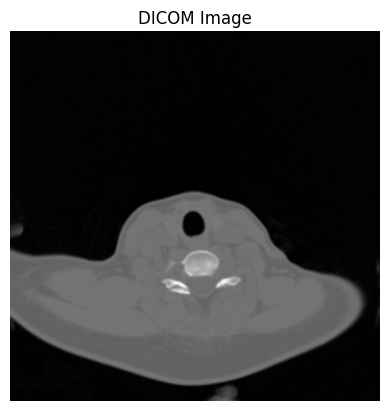

In [7]:
# Step 3: Display the image
plt.imshow(image, cmap='gray')

# Add title
plt.title("DICOM Image")

# Remove axes
plt.axis('off')

# Show image
plt.show()

In [8]:

# DISPLAY IMPORTANT DICOM METADATA

print("Patient Name      :", ds.PatientName)
print("Patient ID        :", ds.PatientID)
print("Modality          :", ds.Modality)
print("Image Size        :", ds.Rows, "x", ds.Columns)
print("Pixel Spacing     :", ds.PixelSpacing)
print("Slice Thickness   :", ds.SliceThickness)

Patient Name      : MANDEEP
Patient ID        : MRI COR 1176015
Modality          : CT
Image Size        : 512 x 512
Pixel Spacing     : [0.44726563, 0.44726563]
Slice Thickness   : 1.0000000


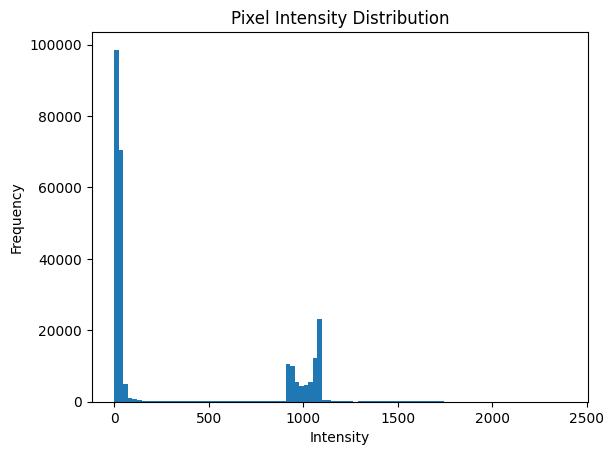

In [9]:

plt.hist(image.flatten(), bins=100)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

In [10]:
hu_image = image * ds.RescaleSlope + ds.RescaleIntercept

In [12]:

# LOAD MULTIPLE DICOM SLICES

import os
import pydicom

folder_path = "/kaggle/input/datasets/maheshnitrkl/aiba-dicom/DICOM_DATA/CT/24 MANDEEP KAUR"

slices = []

# Read all DICOM files
for file in os.listdir(folder_path):

    if file.endswith(".dcm"):

        path = os.path.join(folder_path, file)

        ds = pydicom.dcmread(path)

        slices.append(ds)

# Sort slices using slice location
slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

print("Number of slices:", len(slices))

Number of slices: 226


In [38]:

volume = np.stack([s.pixel_array for s in slices])
print("Volume Shape:", volume.shape)

Volume Shape: (226, 512, 512)


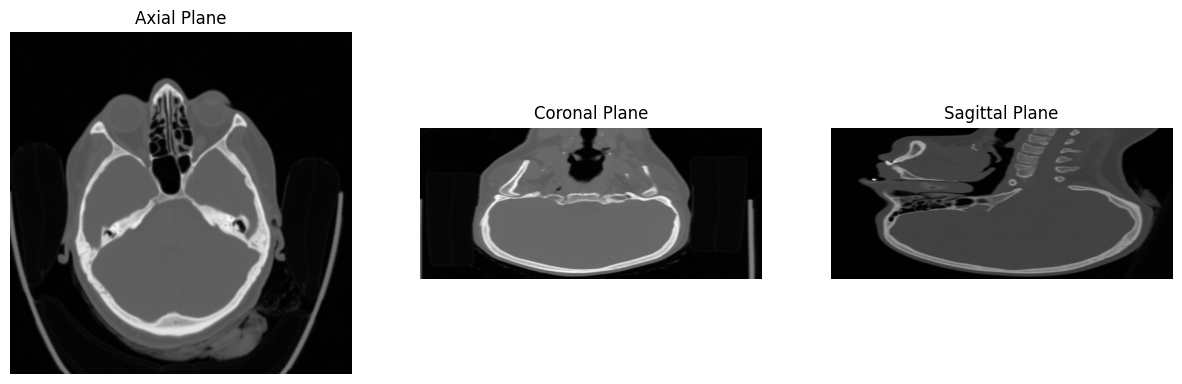

In [48]:
# ----------------------------------------
# DISPLAY AXIAL, CORONAL, SAGITTAL PLANES
# ----------------------------------------

import matplotlib.pyplot as plt

# Select slice indices
z = volume.shape[0] // 2   # Axial
y = volume.shape[1] // 2   # Coronal
x = volume.shape[2] // 2   # Sagittal

# Extract planes
axial = volume[z, :, :]

coronal = volume[:, y, :]

sagittal = volume[:, :, x]

'''coronal = np.flipud(volume[:, y, :])


sagittal = np.flipud(volume[:, :, x])


pixel_spacing = slices[0].PixelSpacing

slice_thickness = slices[0].SliceThickness

# Scaling factor
K = slice_thickness / pixel_spacing[0]

print("Scaling Factor K =", K)
'''

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ----------------------------------------
# AXIAL VIEW
# ----------------------------------------

axes[0].imshow(axial, cmap='gray')

axes[0].set_title("Axial Plane")

axes[0].axis('off')

# ----------------------------------------
# CORONAL VIEW
# ----------------------------------------

axes[1].imshow(coronal, cmap='gray')

axes[1].set_title("Coronal Plane")

axes[1].axis('off')

# ----------------------------------------
# SAGITTAL VIEW
# ----------------------------------------

axes[2].imshow(sagittal, cmap='gray')

axes[2].set_title("Sagittal Plane")

axes[2].axis('off')

# Show all views
plt.show()

In [ ]:
slices[0].PixelSpacing

In [ ]:
slices[0].SliceThickness